In [1]:
import pandas as pd
import numpy as np

In [3]:
features=pd.read_csv(r"C:\Users\HP\Desktop\CHU\PFE_CHU_Attendance_System\etl\features.csv")
print("Shape :" , features.shape)
print("n\Infos :")
print(features.info())
print("\nValeurs manquantes:")
print(features.isnull().sum())

Shape : (41, 8)
n\Infos :
<class 'pandas.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   intern_id                  41 non-null     str    
 1   taux_presence              41 non-null     float64
 2   retard_moyen_min           41 non-null     float64
 3   variabilite_horaire        41 non-null     float64
 4   max_absences_consecutives  41 non-null     int64  
 5   score_irregularite         40 non-null     float64
 6   score_engagement           41 non-null     float64
 7   risk_label                 41 non-null     str    
dtypes: float64(5), int64(1), str(2)
memory usage: 2.7 KB
None

Valeurs manquantes:
intern_id                    0
taux_presence                0
retard_moyen_min             0
variabilite_horaire          0
max_absences_consecutives    0
score_irregularite           1
score_engagement             0
risk_label            

<>:3: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
<>:3: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_11432\4019712409.py:3: SyntaxWarning: "\I" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\I"? A raw string is also an option.
  print("n\Infos :")


In [11]:
features.describe().round(2)

,taux_presence,retard_moyen_min,variabilite_horaire,max_absences_consecutives,score_irregularite,score_engagement
count,41.00,41.00,41.00,41.00,40.00,41.00
mean,79.99,12.11,0.60,1.90,0.09,85.70
std,23.30,15.75,0.12,1.85,0.01,14.51
min,2.27,0.00,0.00,0.00,0.06,16.14
25%,68.18,0.00,0.58,1.00,0.08,82.82
50%,90.91,0.00,0.62,1.00,0.09,86.04
75%,97.73,29.92,0.66,2.00,0.10,96.43
max,100.00,50.00,0.76,7.00,0.12,99.86


In [12]:
# Remplir la valeur manquante par la médiane
features["score_irregularite"] = features["score_irregularite"].fillna(
    features["score_irregularite"].median()
)

print(" Valeurs manquantes après nettoyage :")
print(features.isnull().sum())

 Valeurs manquantes après nettoyage :
intern_id                    0
taux_presence                0
retard_moyen_min             0
variabilite_horaire          0
max_absences_consecutives    0
score_irregularite           0
score_engagement             0
risk_label                   0
dtype: int64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print(" Libraries chargées ")

 Libraries chargées 


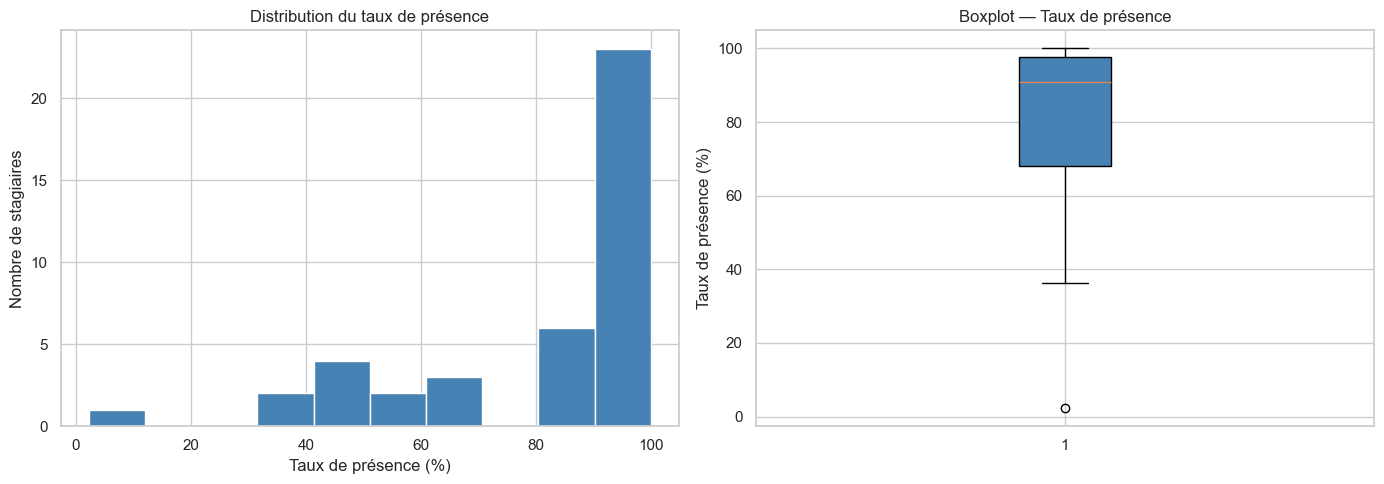

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(features["taux_presence"], bins=10, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution du taux de présence")
axes[0].set_xlabel("Taux de présence (%)")
axes[0].set_ylabel("Nombre de stagiaires")

# Boxplot
axes[1].boxplot(features["taux_presence"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue"))
axes[1].set_title("Boxplot — Taux de présence")
axes[1].set_ylabel("Taux de présence (%)")

plt.tight_layout()
plt.show()

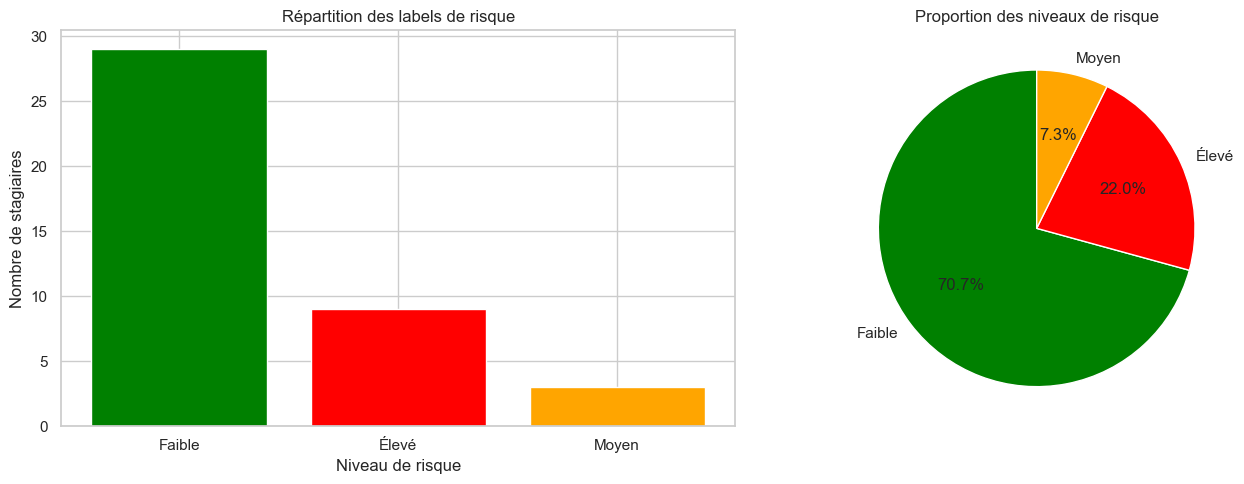

In [16]:
# Répartition des labels de risque
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Countplot
colors = {"Faible": "green", "Moyen": "orange", "Élevé": "red"}
counts = features["risk_label"].value_counts()

axes[0].bar(counts.index, counts.values, 
            color=[colors[x] for x in counts.index])
axes[0].set_title("Répartition des labels de risque")
axes[0].set_xlabel("Niveau de risque")
axes[0].set_ylabel("Nombre de stagiaires")

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=[colors[x] for x in counts.index],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Proportion des niveaux de risque")

plt.tight_layout()
plt.show()

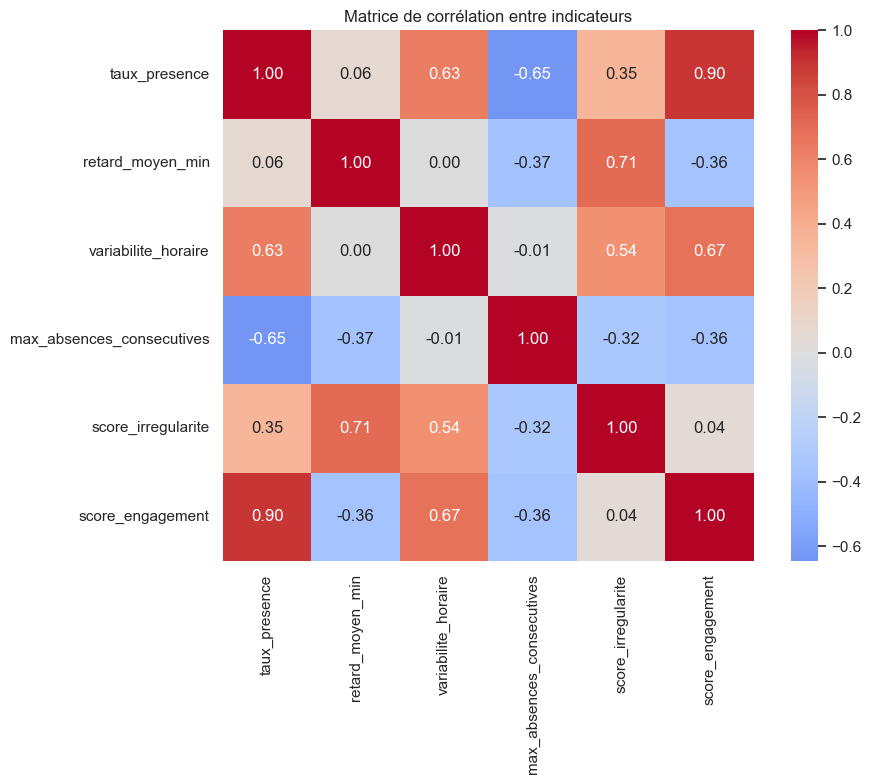

In [18]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
corr = features.drop(columns=["intern_id", "risk_label"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True)
plt.title("Matrice de corrélation entre indicateurs")
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_11432\1091346090.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=features, x="risk_label", y="score_engagement",


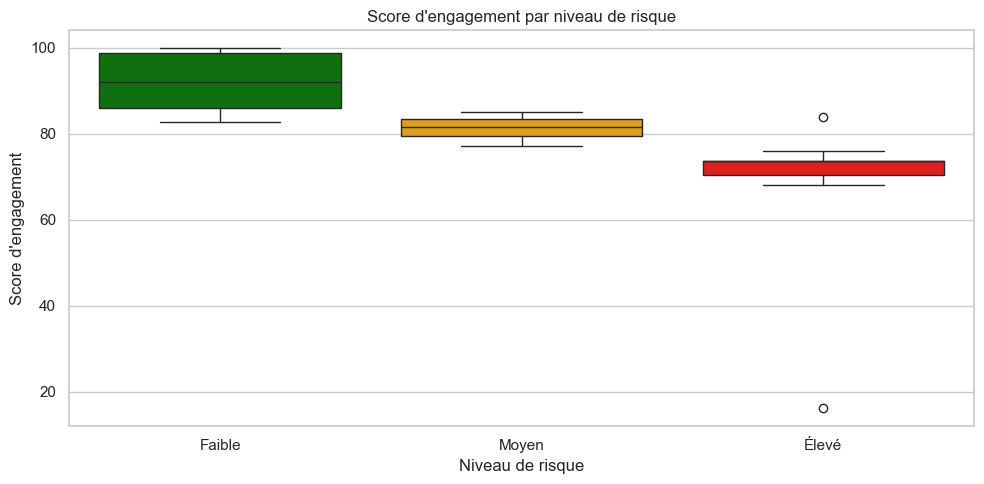

In [21]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=features, x="risk_label", y="score_engagement",
            palette={"Faible": "green", "Moyen": "orange", "Élevé": "red"},
            order=["Faible", "Moyen", "Élevé"])
plt.title("Score d'engagement par niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Score d'engagement")
plt.tight_layout()
plt.show()

In [22]:
from scipy import stats

print("Test de normalité de Shapiro-Wilk \n")

for col in ["taux_presence", "retard_moyen_min", 
            "score_engagement", "variabilite_horaire"]:
    stat, p = stats.shapiro(features[col])
    normal = " Normale" if p > 0.05 else " Non normale"
    print(f"{col:30} p={p:.4f}  →  {normal}")

Test de normalité de Shapiro-Wilk 

taux_presence                  p=0.0000  →   Non normale
retard_moyen_min               p=0.0000  →   Non normale
score_engagement               p=0.0000  →   Non normale
variabilite_horaire            p=0.0000  →   Non normale


In [23]:
import sqlite3

conn = sqlite3.connect(r"C:\Users\HP\Desktop\CHU\PFE_CHU_Attendance_System\hospital_stage.db")
interns_df = pd.read_sql("SELECT * FROM interns", conn)
deps_df = pd.read_sql("SELECT * FROM departments", conn)

# Fusionner avec features
merged = features.merge(interns_df[["id", "department_id"]], 
                        left_on="intern_id", right_on="id")
merged = merged.merge(deps_df, left_on="department_id", right_on="id")

print("Test Mann-Whitney inter-départements\n")
print(merged.groupby("name")["taux_presence"].mean().round(2))

Test Mann-Whitney inter-départements

name
Cardiologie    89.77
Chirurgie      85.71
Neurologie     82.32
Pédiatrie      76.95
Urgences       68.18
Name: taux_presence, dtype: float64


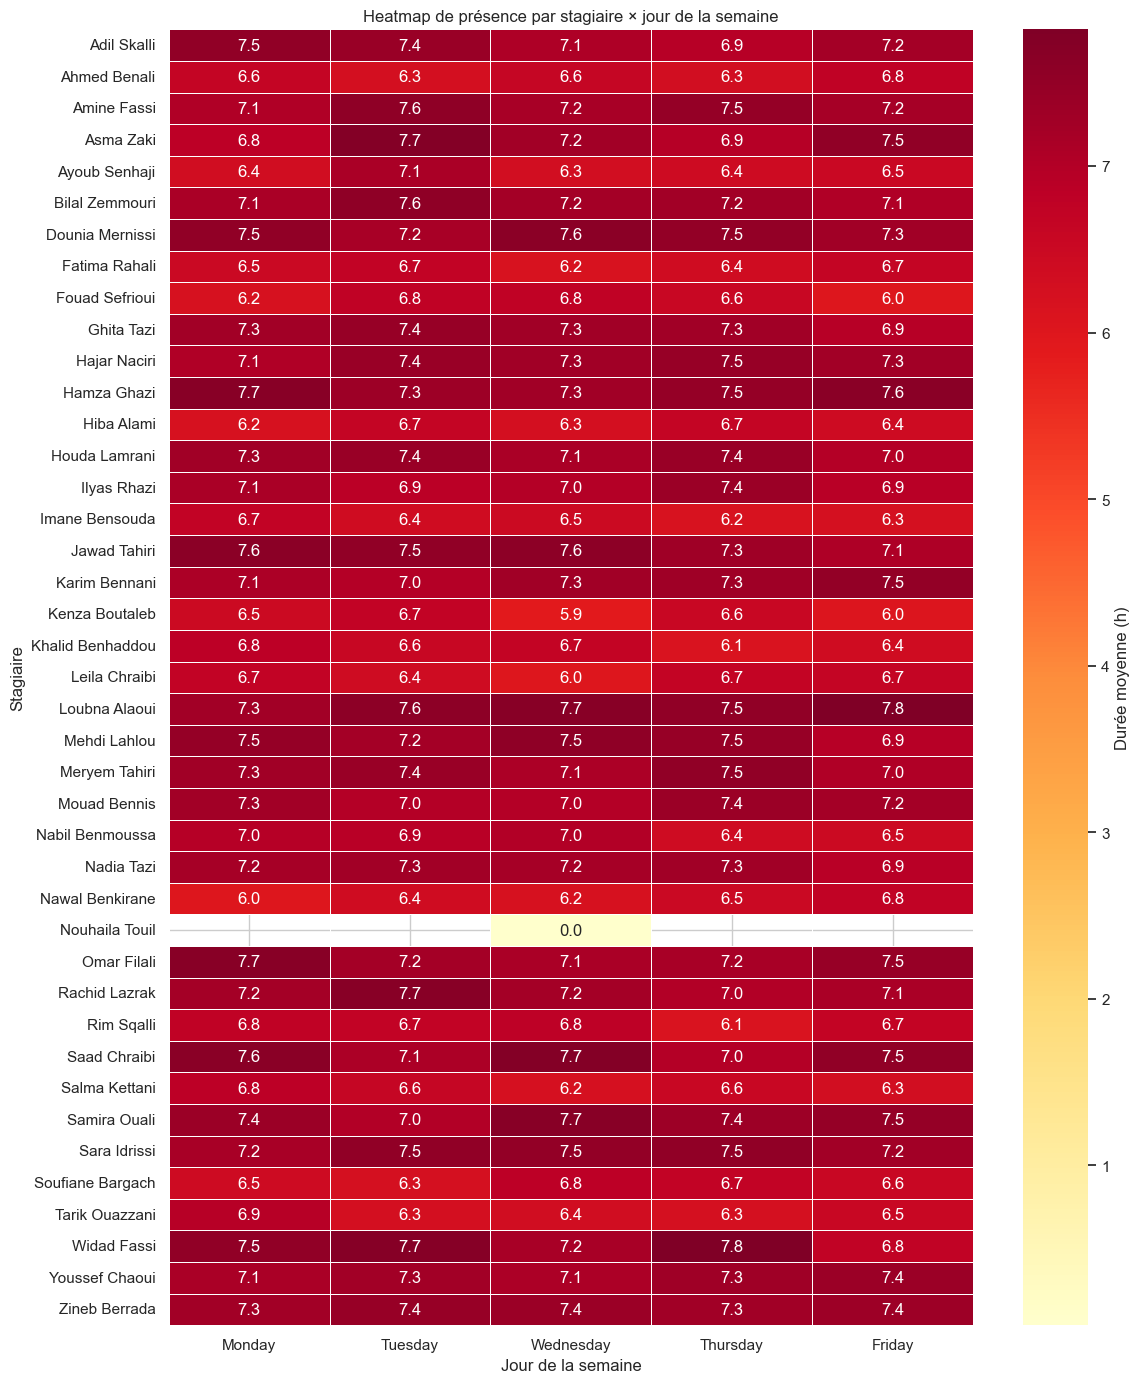

In [24]:
import sqlite3
import numpy as np

conn = sqlite3.connect(r"C:\Users\HP\Desktop\CHU\PFE_CHU_Attendance_System\hospital_stage.db")

daily = pd.read_sql("SELECT * FROM daily_status", conn)
interns_df = pd.read_sql("SELECT * FROM interns", conn)

daily["date"] = pd.to_datetime(daily["date"])
daily["jour_semaine"] = daily["date"].dt.day_name()

# Fusionner avec noms
daily = daily.merge(interns_df[["id", "first_name", "last_name"]], 
                    left_on="intern_id", right_on="id")
daily["nom_complet"] = daily["first_name"] + " " + daily["last_name"]

# Créer la heatmap
pivot = daily.pivot_table(
    index="nom_complet",
    columns="jour_semaine",
    values="work_duration",
    aggfunc="mean"
)

# Ordonner les jours
jours = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
pivot = pivot.reindex(columns=jours)

plt.figure(figsize=(12, 14))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.5,
            annot=True, fmt=".1f",
            cbar_kws={"label": "Durée moyenne (h)"})
plt.title("Heatmap de présence par stagiaire × jour de la semaine")
plt.xlabel("Jour de la semaine")
plt.ylabel("Stagiaire")
plt.tight_layout()
plt.show()